使用Sarsa方法对带陷阱的网格世界马尔可夫决策问题进行求解。总体思路是以ε-贪心策略采样数据，生成轨迹。针对每一条轨迹的每个时间步，进行一次策略评估，更新状态行为对的行为值函数

In [ ]:
import pandas as pd
import numpy as np

from lib.envs.maze import MazeEnv

In [ ]:
class RL():
    def __init__(self, action_space, 
                 learning_rate=0.1, 
                 reward_decay =0.9, 
                 e_greedy     =0.9
                 ):
        
        self.actions = action_space
        self.lr = learning_rate
        self.gamma = reward_decay
        self.epsilon = e_greedy
        self.q_table = pd.DataFrame(columns=self.actions, dtype=np.float64)
        
    def check_state_exist(self, state):
        if state not in self.q_table.index:
            # 如果状态在当前的 Q 表中不存在,将当前状态加入 Q 表中
            new_row = pd.DataFrame(
                [[0.0] * len(self.actions)],
                columns=self.q_table.columns,
                index=[state]
            )
            self.q_table = pd.concat([self.q_table, new_row])

    def choose_action(self, observation):
        self.check_state_exist(observation)
        # 从均匀分布的[0,1]中随机采样,当小于阈值时采用选择最优行为的方式,
        # 当大于阈值时采用选择随机行为的方式,这样人为增加随机性是为了解决陷入局部最优
        
        # 最优行为概率：ε + (1-ε)/|A|
        # 其它行为概率：(1-ε)/|A|
        if np.random.rand() <= self.epsilon:
            # 选择最优行为
            state_action = self.q_table.loc[observation, :]
            # 因为一个状态下最优行为可能有多个,需要随机选择一个
            max_val = state_action.max()
            best_actions = state_action[state_action == max_val].index.tolist()
            action = np.random.choice(best_actions)
        else:
            # 选择随机行为
            action = np.random.choice(self.actions)
        return action

    def learn(self, *args):
        pass

In [ ]:
# 在线策略 Sarsa
class SarsaTable(RL):  # 继承 RL 基类
    def __init__(self, actions, 
                 learning_rate=0.1, 
                 reward_decay =0.9, 
                 e_greedy     =0.9
                 ):
        super().__init__(actions, learning_rate, reward_decay, e_greedy)

    def learn(self, s, a, r, s_, a_):
        self.check_state_exist(s)
        self.check_state_exist(s_)
        
        q_predict = self.q_table.loc[s, a]

        if s_ != 'terminal':
            # 使用公式: Q_target = r + γQ(s',a')
            q_target = r + self.gamma * self.q_table.loc[s_, a_]
        else:
            q_target = r

        # 更新公式: Q(s,a) ← Q(s,a) + α(r + γQ(s',a') − Q(s,a))
        self.q_table.loc[s, a] += self.lr * (q_target - q_predict)

    def get_action(self, q_table, state):
        # 选择最优行为
        state_action = q_table.loc[state, :]
        max_val = state_action.max()
        
        idxs = [i for i, v in enumerate(state_action) if v == max_val]
        idxs.sort()
        return tuple(idxs)
    
    def get_policy(self, q_table, env, rows=5, cols=5, pixels=40, origin=20):
        policy = []
        # 预计算所有陷阱和宝藏坐标
        hell_positions = [
            env.canvas.coords(env.hell1), env.canvas.coords(env.hell2),
            env.canvas.coords(env.hell3), env.canvas.coords(env.hell4),
            env.canvas.coords(env.hell5), env.canvas.coords(env.hell6),
            env.canvas.coords(env.hell7), env.canvas.coords(env.oval)
        ]
        
        for i in range(rows):
            for j in range(cols):
                # 求出每个格子的状态
                item_center_x = (j * pixels + origin)
                item_center_y = (i * pixels + origin)
                item_state = [item_center_x - 15.0, 
                              item_center_y - 15.0, 
                              item_center_x + 15.0, 
                              item_center_y + 15.0]
                                
                if item_state in hell_positions:
                    policy.append(-1)
                    continue
                if str(item_state) not in q_table.index:
                    policy.append((0, 1, 2, 3))
                    continue
                # 选择最优行为
                item_action_max = self.get_action(q_table, str(item_state))
                policy.append(item_action_max)
        return policy

In [ ]:
def update(agent, env, episodes=100, render=True, verbose=True):
    """
    Sarsa 训练主循环
    agent: SarsaTable 实例
    env: MazeEnv 实例
    episodes: 训练局数
    render: 是否渲染训练过程
    verbose: 是否打印进度
    返回: policy_grid, metrics
    """
    metrics = {'rewards': [], 'steps': [], 'success': []}

    for episode in range(episodes):
        observation = env.reset()
        ep_reward = 0
        ep_steps = 0
        success = False

        while True:
            if render:
                env.render()

            action = agent.choose_action(str(observation))
            next_obs, reward, done, oval_flag = env.step(action)
            next_action = agent.choose_action(str(next_obs))

            # Sarsa 更新: (s, a, r, s', a')
            agent.learn(str(observation), action, reward, str(next_obs), next_action)

            observation = next_obs
            ep_reward += reward
            ep_steps += 1

            if done:
                success = oval_flag
                break

        metrics['rewards'].append(ep_reward)
        metrics['steps'].append(ep_steps)
        metrics['success'].append(1 if success else 0)

        if verbose and (episode + 1) % 20 == 0:
            print(f'第 {episode + 1} 局结束')

    # 提取最优策略
    policy = agent.get_policy(agent.q_table, env)
    policy_grid = np.array(policy, dtype=object).reshape(5, 5)

    if verbose:
        print('\n最优策略 (0:↑ 1:↓ 2:← 3:→,  -1:障碍/宝藏):')
        print(policy_grid)
        env.render_by_policy(policy_grid)

    return policy_grid, metrics

In [30]:
env = MazeEnv()
agent = SarsaTable(actions=list(range(env.n_actions)))
# 直接调用 update，render=True 可实时观看训练过程
policy_grid, metrics = update(agent, env, episodes=100, render=True, verbose=True)
env.destroy()

第 20 局结束
第 40 局结束
第 60 局结束
第 80 局结束
第 100 局结束

最优策略 (0:↑ 1:↓ 2:← 3:→,  -1:障碍/宝藏):
[[(2,) (0,) (0,) (0,) (1,)]
 [(1,) -1 -1 -1 (0,)]
 [(3,) (3,) (1,) (2,) (3,)]
 [(2,) -1 (1,) -1 (3,)]
 [-1 (0, 1, 2, 3) -1 (0, 1, 2, 3) -1]]


## 可视化分析

以下图表基于训练过程中记录的指标和最终 Q 表生成。

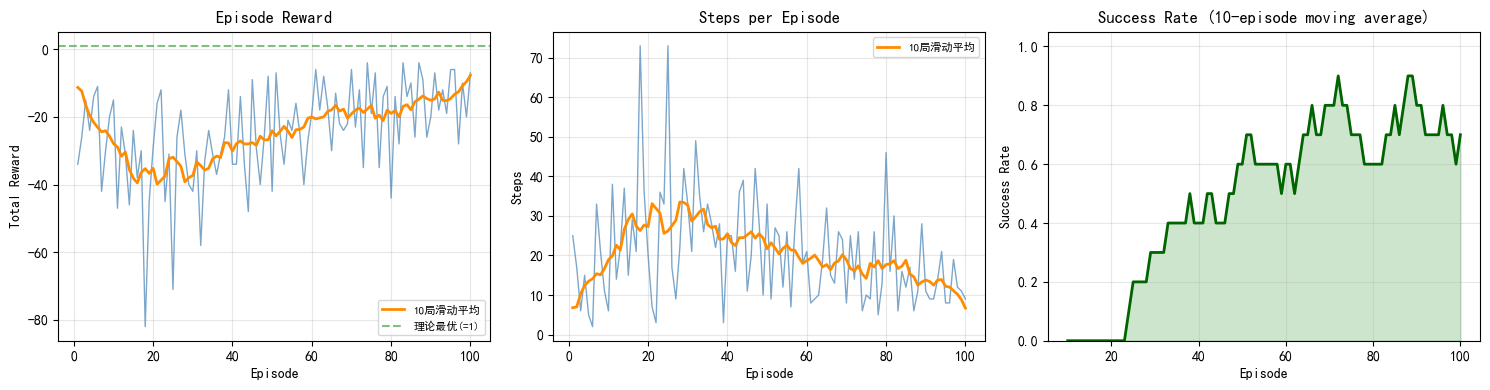

训练统计 (共 100 局):
  最终10局平均奖励: -13.30
  最终10局平均步数: 12.0
  最终10局成功率:   70.0%
  总成功率:         48.0%


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

# 设置中文字体（如果系统支持）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ── 1. 学习曲线 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

episodes_range = np.arange(1, len(metrics['rewards']) + 1)

# 累计奖励
axes[0].plot(episodes_range, metrics['rewards'], color='steelblue', alpha=0.7, linewidth=1)
axes[0].plot(episodes_range, np.convolve(metrics['rewards'], np.ones(10)/10, mode='same'),
             color='darkorange', linewidth=2, label='10局滑动平均')
axes[0].axhline(y=1, color='green', linestyle='--', alpha=0.5, label='理论最优(=1)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Episode Reward')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 步数
axes[1].plot(episodes_range, metrics['steps'], color='steelblue', alpha=0.7, linewidth=1)
axes[1].plot(episodes_range, np.convolve(metrics['steps'], np.ones(10)/10, mode='same'),
             color='darkorange', linewidth=2, label='10局滑动平均')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')
axes[1].set_title('Steps per Episode')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 成功率 (10局滑动窗口)
window = 10
success_ma = np.convolve(metrics['success'], np.ones(window)/window, mode='valid')
axes[2].plot(range(window, len(metrics['success']) + 1), success_ma,
             color='darkgreen', linewidth=2)
axes[2].fill_between(range(window, len(metrics['success']) + 1), 0, success_ma,
                      alpha=0.2, color='green')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Success Rate')
axes[2].set_title(f'Success Rate ({window}-episode moving average)')
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 汇总统计
print(f'训练统计 (共 {len(metrics["rewards"])} 局):')
print(f'  最终10局平均奖励: {np.mean(metrics["rewards"][-10:]):.2f}')
print(f'  最终10局平均步数: {np.mean(metrics["steps"][-10:]):.1f}')
print(f'  最终10局成功率:   {np.mean(metrics["success"][-10:]):.1%}')
print(f'  总成功率:         {np.sum(metrics["success"]) / len(metrics["success"]):.1%}')

C:\Users\xin\AppData\Local\Temp\ipykernel_26588\3079692385.py:68: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) SimHei.
  plt.tight_layout()
d:\MyDocs\Pro_Learn\reinforcement_learning\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


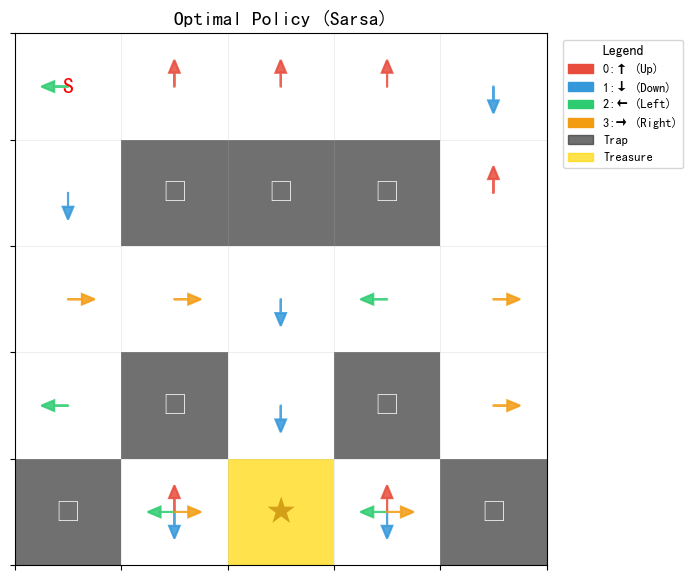

In [32]:
# ── 2. 最优策略网格图 ──
action_labels = {0: '↑', 1: '↓', 2: '←', 3: '→'}
action_colors = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))
ax.grid(True, linewidth=0.5, alpha=0.3)
ax.set_aspect('equal')
ax.tick_params(labelleft=False, labelbottom=False)

# 陷阱和宝藏位置 (col, row) 0-indexed from top-left
trap_positions = [(1, 1), (2, 1), (3, 1), (1, 3), (3, 3), (0, 4), (4, 4)]
treasure_pos = (2, 4)

for i in range(5):
    for j in range(5):
        action = policy_grid[i, j]
        # 绘图坐标 (y 翻转)
        cx, cy = j + 0.5, 4 - i + 0.5

        # 陷阱
        if (j, i) in trap_positions:
            ax.add_patch(plt.Rectangle((j, 4-i), 1, 1, facecolor='#333', alpha=0.7))
            ax.text(cx, cy, '✕', ha='center', va='center', fontsize=18, color='white', fontweight='bold')
            continue

        # 宝藏
        if (j, i) == treasure_pos:
            ax.add_patch(plt.Rectangle((j, 4-i), 1, 1, facecolor='gold', alpha=0.7))
            ax.text(cx, cy, '★', ha='center', va='center', fontsize=22, color='#D4A017')
            continue

        # 普通格子: 画箭头
        if action == -1:
            continue

        for a in action:
            dx, dy = 0, 0
            if a == 0: dy = 0.25      # 上
            elif a == 1: dy = -0.25   # 下
            elif a == 2: dx = -0.25   # 左
            elif a == 3: dx = 0.25    # 右
            else: continue

            ax.arrow(cx, cy, dx, dy,
                     head_width=0.1, head_length=0.12,
                     fc=action_colors[a], ec=action_colors[a],
                     alpha=0.85, linewidth=1.5, length_includes_head=True)

# 起点标记
ax.text(0.5, 4.5, 'S', ha='center', va='center', fontsize=16, fontweight='bold', color='red')

# 图例
legend_patches = [mpatches.Patch(color=c, label=f'{lbl} ({name})')
                  for name, (lbl, c) in {'Up': ('0:↑', '#E74C3C'),
                                          'Down': ('1:↓', '#3498DB'),
                                          'Left': ('2:←', '#2ECC71'),
                                          'Right': ('3:→', '#F39C12')}.items()]
legend_patches += [mpatches.Patch(color='#333', alpha=0.7, label='Trap'),
                   mpatches.Patch(color='gold', alpha=0.7, label='Treasure')]
ax.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.02, 1),
          fontsize=9, title='Legend', title_fontsize=10)

ax.set_title('Optimal Policy (Sarsa)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\xin\AppData\Local\Temp\ipykernel_26588\2312775796.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


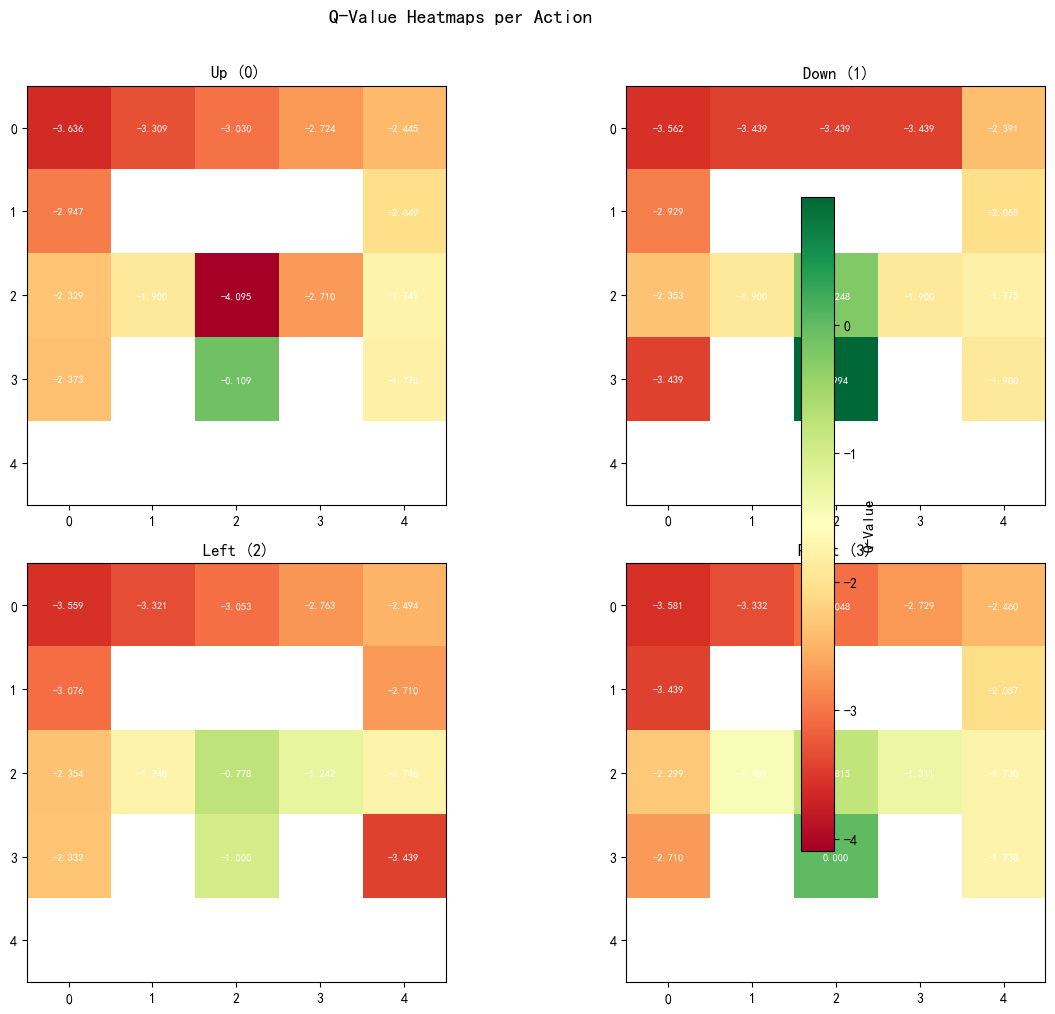

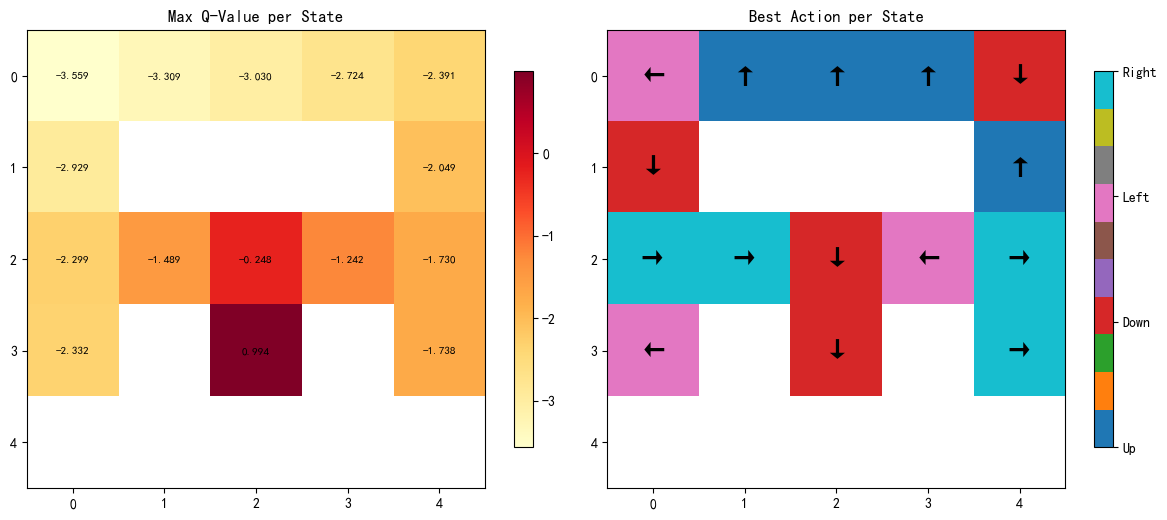

In [33]:
# ── 3. Q 值热力图 ──
action_names = ['Up (0)', 'Down (1)', 'Left (2)', 'Right (3)']
pixels, origin = 40, 20

# 从 Q 表中提取每个动作在 5×5 网格上的 Q 值
q_grids = np.zeros((4, 5, 5))
# 记录哪些格子被访问过
visited_mask = np.zeros((5, 5), dtype=bool)

for i in range(5):
    for j in range(5):
        cx = j * pixels + origin
        cy = i * pixels + origin
        state_str = str([cx-15.0, cy-15.0, cx+15.0, cy+15.0])
        if state_str in agent.q_table.index:
            visited_mask[i, j] = True
            for a in range(4):
                q_grids[a, i, j] = agent.q_table.loc[state_str, a]

vmin = q_grids.min()
vmax = q_grids.max()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = plt.cm.RdYlGn

for a, ax in enumerate(axes.flat):
    # 对未访问格子做遮罩
    masked = np.ma.masked_where(~visited_mask, q_grids[a])
    im = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(action_names[a], fontsize=12, fontweight='bold')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))

    # 标注数值
    for i in range(5):
        for j in range(5):
            if visited_mask[i, j]:
                val = q_grids[a, i, j]
                color = 'white' if abs(val) > (vmax + vmin) / 2 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7.5,
                        color=color, fontweight='bold')

# 统一 colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label('Q-Value', fontsize=11)

fig.suptitle('Q-Value Heatmaps per Action', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 最优动作的 Q 值（每个格子取 max Q）
best_q = q_grids.max(axis=0)
best_action = q_grids.argmax(axis=0)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 最优 Q 值热力图
im1 = ax1.imshow(np.ma.masked_where(~visited_mask, best_q),
                  cmap='YlOrRd', aspect='equal')
ax1.set_title('Max Q-Value per State', fontsize=12, fontweight='bold')
ax1.set_xticks(range(5))
ax1.set_yticks(range(5))
for i in range(5):
    for j in range(5):
        if visited_mask[i, j]:
            ax1.text(j, i, f'{best_q[i,j]:.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=ax1, shrink=0.8)

# 最优动作分布
action_cmap = plt.cm.tab10
im2 = ax2.imshow(np.ma.masked_where(~visited_mask, best_action),
                  cmap=action_cmap, vmin=0, vmax=3, aspect='equal')
ax2.set_title('Best Action per State', fontsize=12, fontweight='bold')
ax2.set_xticks(range(5))
ax2.set_yticks(range(5))
sym = {0: '↑', 1: '↓', 2: '←', 3: '→'}
for i in range(5):
    for j in range(5):
        if visited_mask[i, j]:
            ax2.text(j, i, sym[best_action[i, j]], ha='center', va='center',
                     fontsize=18)
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8, ticks=[0, 1, 2, 3])
cbar2.set_ticklabels(['Up', 'Down', 'Left', 'Right'])

plt.tight_layout()
plt.show()

In [ ]:
# ── 4. 智能体走迷宫路径 ──
# 用训练好的 Q 表，在新环境中以纯贪婪策略走一次
eval_env = MazeEnv()
# 临时设置 epsilon=1 确保纯贪婪（不做探索）
saved_epsilon = agent.epsilon
agent.epsilon = 1.0

observation = eval_env.reset()
path_states = [observation]       # 记录状态序列
path_centers = []                 # 记录格子中心坐标
actions_taken = []
total_reward = 0

while True:
    eval_env.render()
    state_str = str(observation)
    action = agent.choose_action(state_str)
    next_obs, reward, done, oval_flag = eval_env.step(action)

    # 记录当前格子中心 (归一化到 [0,5] 网格坐标)
    cx = (observation[0] + observation[2]) / 2
    cy = (observation[1] + observation[3]) / 2
    path_centers.append((cx, cy))
    actions_taken.append(action)
    total_reward += reward

    if done:
        path_states.append(next_obs)
        break
    observation = next_obs

agent.epsilon = saved_epsilon  # 恢复 epsilon
success = oval_flag
eval_env.destroy()

# ── 绘制路径 ──
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 200)
ax.set_ylim(200, 0)  # y 向下增大
ax.set_xticks(np.arange(0, 201, 40))
ax.set_yticks(np.arange(0, 201, 40))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# 绘制网格格子背景色
trap_centers_mpl = [(60, 60), (100, 60), (140, 60), (60, 140), (140, 140), (20, 180), (180, 180)]
treasure_center_mpl = (100, 180)

for tc in trap_centers_mpl:
    ax.add_patch(plt.Rectangle((tc[0]-20, tc[1]-20), 40, 40,
                 facecolor='#333', alpha=0.5))
    ax.text(tc[0], tc[1], '✕', ha='center', va='center', fontsize=24, color='white', fontweight='bold')

ax.add_patch(plt.Rectangle((treasure_center_mpl[0]-20, treasure_center_mpl[1]-20), 40, 40,
             facecolor='gold', alpha=0.5))
ax.text(treasure_center_mpl[0], treasure_center_mpl[1], '★', ha='center', va='center',
        fontsize=28, color='#D4A017')

# 绘制路径
xs = [p[0] for p in path_centers]
ys = [p[1] for p in path_centers]

# 连线
for k in range(len(path_centers) - 1):
    ax.annotate('', xy=(xs[k+1], ys[k+1]), xytext=(xs[k], ys[k]),
                arrowprops=dict(arrowstyle='->', color='#E74C3C',
                               lw=2.5, connectionstyle='arc3,rad=0'))

# 标记每个位置
for k, (x, y) in enumerate(path_centers):
    color = 'green' if k == 0 else ('gold' if k == len(path_centers)-1 else 'red')
    size = 120 if k == 0 else (150 if k == len(path_centers)-1 else 80)
    ax.scatter(x, y, c=color, s=size, zorder=5, edgecolors='white', linewidth=1.5)
    
    # 动作标注
    if k < len(actions_taken):
        a = actions_taken[k]
        sym = {0: '↑', 1: '↓', 2: '←', 3: '→'}
        ax.text(x, y, sym[a], ha='center', va='center', fontsize=10,
                color='white', fontweight='bold')

# 起点和终点标注
ax.text(20, 35, 'START', ha='center', va='top', fontsize=10, fontweight='bold', color='green')
if success:
    ax.text(treasure_center_mpl[0], treasure_center_mpl[1]-25, 'GOAL!', ha='center', va='top',
            fontsize=12, fontweight='bold', color='#D4A017')

status_text = '✓ 成功到达宝藏!' if success else '✗ 落入陷阱'
title_color = 'green' if success else 'red'
ax.set_title(f'Agent Path Trace — {status_text}\n'
             f'Steps: {len(path_centers)} | Total Reward: {total_reward} | '
             f'Path Length: {len(path_centers)-1} moves',
             fontsize=13, fontweight='bold', color=title_color)

plt.tight_layout()
plt.show()

print(f'路径追踪结果:')
print(f'  状态:  {"成功" if success else "失败"}')
print(f'  步数:  {len(path_centers) - 1}')
print(f'  奖励:  {total_reward}')
print(f'  路径:  {" → ".join({0:"↑",1:"↓",2:"←",3:"→"}[a] for a in actions_taken)}')

TclError: invalid command name ".!canvas"

: 

In [ ]:
# ── 5. ε 参数敏感性分析 ──
import time as time_module

def train_fast(epsilon, episodes=100):
    """快速训练（无渲染），返回 metrics"""
    from lib.envs.Maze import MazeEnv
    env = MazeEnv()
    # 让窗口不显示
    env.withdraw()
    agent = SarsaTable(actions=list(range(env.n_actions)), e_greedy=epsilon)
    _, metrics = update(agent, env, episodes=episodes, render=False, verbose=False)
    env.destroy()
    return metrics

# 测试不同 ε 值
epsilons = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
episodes_test = 100
results = {}

print('正在进行 ε 参数敏感性分析...')
for eps in epsilons:
    t0 = time_module.time()
    results[eps] = train_fast(eps, episodes=episodes_test)
    elapsed = time_module.time() - t0
    final_sr = np.mean(results[eps]['success'][-10:])
    print(f'  ε={eps:.1f}  完成 ({elapsed:.1f}s)  最终10局成功率: {final_sr:.1%}')

# ── 绘制对比图 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(epsilons)))
ep_range = np.arange(1, episodes_test + 1)

for eps, color in zip(epsilons, colors):
    m = results[eps]
    # 奖励 (滑动平均)
    reward_ma = np.convolve(m['rewards'], np.ones(10)/10, mode='same')
    axes[0, 0].plot(ep_range, reward_ma, color=color, linewidth=1.5, alpha=0.8, label=f'ε={eps:.1f}')
    
    # 步数 (滑动平均)
    steps_ma = np.convolve(m['steps'], np.ones(10)/10, mode='same')
    axes[0, 1].plot(ep_range, steps_ma, color=color, linewidth=1.5, alpha=0.8, label=f'ε={eps:.1f}')
    
    # 成功率 (滑动窗口)
    success_ma = np.convolve(m['success'], np.ones(10)/10, mode='valid')
    axes[1, 0].plot(range(10, episodes_test + 1), success_ma, color=color, linewidth=1.5, alpha=0.8,
                    label=f'ε={eps:.1f}')

# 奖励
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Avg Reward (MA=10)')
axes[0, 0].set_title('Reward vs ε')
axes[0, 0].legend(fontsize=8, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# 步数
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Avg Steps (MA=10)')
axes[0, 1].set_title('Steps vs ε')
axes[0, 1].legend(fontsize=8, ncol=2)
axes[0, 1].grid(True, alpha=0.3)

# 成功率
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Success Rate (window=10)')
axes[1, 0].set_title('Success Rate vs ε')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].legend(fontsize=8, ncol=2)
axes[1, 0].grid(True, alpha=0.3)

# 柱状图: 最终成功率
final_success = [np.mean(results[eps]['success'][-20:]) for eps in epsilons]
bars = axes[1, 1].bar([str(e) for e in epsilons], final_success,
                      color=colors, edgecolor='white', linewidth=1.5)
axes[1, 1].set_xlabel('ε (exploration rate)')
axes[1, 1].set_ylabel('Final Success Rate')
axes[1, 1].set_title('Final Success Rate (last 20 episodes)')
axes[1, 1].set_ylim(0, 1.1)
for bar, val in zip(bars, final_success):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.1%}', ha='center', fontweight='bold', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('ε Sensitivity Analysis (Sarsa)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 汇总表
print('\nε 参数对比汇总:')
print(f'{"ε":>6}  {"最终奖励":>10}  {"最终步数":>10}  {"最终成功率":>10}  {"总成功率":>10}')
print('-' * 55)
for eps in epsilons:
    m = results[eps]
    print(f'{eps:>6.1f}  {np.mean(m["rewards"][-20:]):>10.2f}  '
          f'{np.mean(m["steps"][-20:]):>10.1f}  '
          f'{np.mean(m["success"][-20:]):>10.1%}  '
          f'{np.sum(m["success"])/len(m["success"]):>10.1%}')

In [ ]:
# ── 6. 补充可视化: 状态访问分布 + 算法对比说明 ──

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 左图: 状态访问情况 ---
pixels, origin = 40, 20
visited_grid = np.zeros((5, 5), dtype=int)
for i in range(5):
    for j in range(5):
        cx = j * pixels + origin
        cy = i * pixels + origin
        state_str = str([cx-15.0, cy-15.0, cx+15.0, cy+15.0])
        if state_str in agent.q_table.index:
            visited_grid[i, j] = 1

im1 = axes[0].imshow(visited_grid, cmap='Blues', aspect='equal', alpha=0.8)
axes[0].set_title('States in Q-Table (visited during training)', fontsize=11, fontweight='bold')
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
for i in range(5):
    for j in range(5):
        emoji = '✓' if visited_grid[i, j] else '?'
        color = 'darkgreen' if visited_grid[i, j] else 'darkred'
        axes[0].text(j, i, emoji, ha='center', va='center', fontsize=16, color=color)

# 标记特殊格子
trap_positions = [(1,1),(2,1),(3,1),(1,3),(3,3),(0,4),(4,4)]
for j, i in trap_positions:
    axes[0].add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                     edgecolor='red', linewidth=2, linestyle='--'))

# --- 右图: 网格环境示意 ---
axes[1].set_xlim(0, 5)
axes[1].set_ylim(0, 5)
axes[1].set_xticks(range(6))
axes[1].set_yticks(range(6))
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')
axes[1].set_title('Environment Layout', fontsize=11, fontweight='bold')

# 陷阱
for j, i in trap_positions:
    axes[1].add_patch(plt.Rectangle((j, 4-i), 1, 1, facecolor='#333', alpha=0.6))
# 宝藏
axes[1].add_patch(plt.Rectangle((2, 0), 1, 1, facecolor='gold', alpha=0.7))
axes[1].text(2.5, 0.5, '★', ha='center', va='center', fontsize=20, color='#D4A017')
# 起点
axes[1].add_patch(plt.Rectangle((0, 4), 1, 1, facecolor='lightgreen', alpha=0.5))
axes[1].text(0.5, 4.5, 'S', ha='center', va='center', fontsize=14, fontweight='bold', color='green')
# 标签
for j, i in trap_positions:
    axes[1].text(j+0.5, 4-i+0.5, 'T', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 最终汇总仪表板 ──
print('=' * 60)
print('  Sarsa 网格世界 — 训练报告')
print('=' * 60)
print(f'  算法:        Sarsa (on-policy TD Control)')
print(f'  学习率 α:    {agent.lr}')
print(f'  折扣因子 γ:  {agent.gamma}')
print(f'  探索率 ε:    {agent.epsilon}')
print(f'  训练局数:    {len(metrics["rewards"])}')
print(f'  探索状态数:  {len(agent.q_table)} (含 terminal)')
print('─' * 60)
print(f'  最终成功率:  {np.mean(metrics["success"][-20:]):.1%} (最后20局)')
print(f'  全程成功率:  {np.sum(metrics["success"])/len(metrics["success"]):.1%}')
print(f'  平均步数:    {np.mean(metrics["steps"][-20:]):.1f} (最后20局)')
print(f'  平均奖励:    {np.mean(metrics["rewards"][-20:]):.2f} (最后20局)')
print(f'  最优路径步数:{np.min(metrics["steps"]):.0f}')
print('=' * 60)